In [2]:
import pandas as pd

# 加载所有相关的数据文件
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
name_translation = pd.read_csv('product_category_name_translation.csv')

# --- 核心处理步骤（完全复刻第一次的逻辑） ---

# 1. 转换时间格式
date_columns = [
    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date'
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# 2. 筛选已送达订单并进行必要的合并
# 注意：这里的清洗和合并逻辑，将严格按照第一次的顺序
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

# 3. 计算所有时效和延迟指标
delivered_orders['seller_prep_time_hours'] = (delivered_orders['order_delivered_carrier_date'] - delivered_orders['order_approved_at']).dt.total_seconds() / 3600
delivered_orders['shipping_time_hours'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_delivered_carrier_date']).dt.total_seconds() / 3600
delivered_orders['total_fulfillment_time_hours'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.total_seconds() / 3600

# 延迟计算： 这是最关键的地方，完全复原当时的方法
delivered_orders['delivery_delay_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']).dt.days
delivered_orders['is_delayed'] = delivered_orders['delivery_delay_days'] > 0

# 4. 将所有数据合并成一个总表
final_df = pd.merge(delivered_orders, customers, on='customer_id')
final_df = pd.merge(final_df, order_items, on='order_id')
final_df = pd.merge(final_df, products, on='product_id')
final_df = pd.merge(final_df, name_translation, on='product_category_name', how='left')
final_df['product_category_name_english'].fillna('other', inplace=True)

# 5. 基于这个总表进行分组聚合
state_timeliness_agg = final_df.groupby('customer_state').agg(
    avg_prep_time_hours=('seller_prep_time_hours', 'mean'),
    avg_shipping_time_hours=('shipping_time_hours', 'mean'),
    avg_total_time_hours=('total_fulfillment_time_hours', 'mean'),
    delay_rate=('is_delayed', 'mean')
).reset_index()

state_timeliness_sorted = state_timeliness_agg.sort_values(by='avg_total_time_hours', ascending=False)

print("--- 【基准版】各州平均物流时效（履约最慢的前10个州）---")
print(state_timeliness_sorted.head(10))

--- 【基准版】各州平均物流时效（履约最慢的前10个州）---
   customer_state  avg_prep_time_hours  avg_shipping_time_hours  \
21             RR            78.309710               589.776286   
3              AP            69.797130               589.478045   
2              AM            59.710908               564.294330   
1              AL            75.832049               500.181110   
13             PA            70.781653               487.093454   
9              MA            78.665573               426.492752   
24             SE            78.299049               426.635909   
5              CE            69.340952               422.593165   
0              AC            67.912085               415.604350   
14             PB            72.791222               406.440503   

    avg_total_time_hours  delay_rate  
21            677.544275    0.108696  
3             676.943035    0.037037  
2             633.383212    0.030675  
1             587.739403    0.208431  
13            570.097281    0.1129

C:\Users\79926\AppData\Local\Temp\ipykernel_8564\506874410.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['product_category_name_english'].fillna('other', inplace=True)


C:\Users\79926\AppData\Local\Temp\ipykernel_8564\2216532979.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['product_category_name_english'].fillna('other', inplace=True)
C:\Users\79926\AppData\Local\Temp\ipykernel_8564\2216532979.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus

--- 开始第二步：成本分析 ---

--- 各州平均运费与运费占比 (平均运费最高的前10个州) ---
                avg_freight_value  avg_freight_ratio
customer_state                                      
PB                      43.091689           0.288982
RR                      43.088043           0.316362
RO                      41.330549           0.319655
AC                      40.047912           0.287717
PI                      39.115086           0.283073
MA                      38.492712           0.304732
TO                      37.435032           0.290778
SE                      36.573173           0.278167
AL                      35.870656           0.265299
RN                      35.718081           0.282302

--- 各品类平均运费与运费占比 (平均运费最高的前10个品类，订单数>30) ---
                                         order_count  avg_freight_value  \
product_category_name_english                                             
computers                                        177          48.570955   
home_appliances_2                      

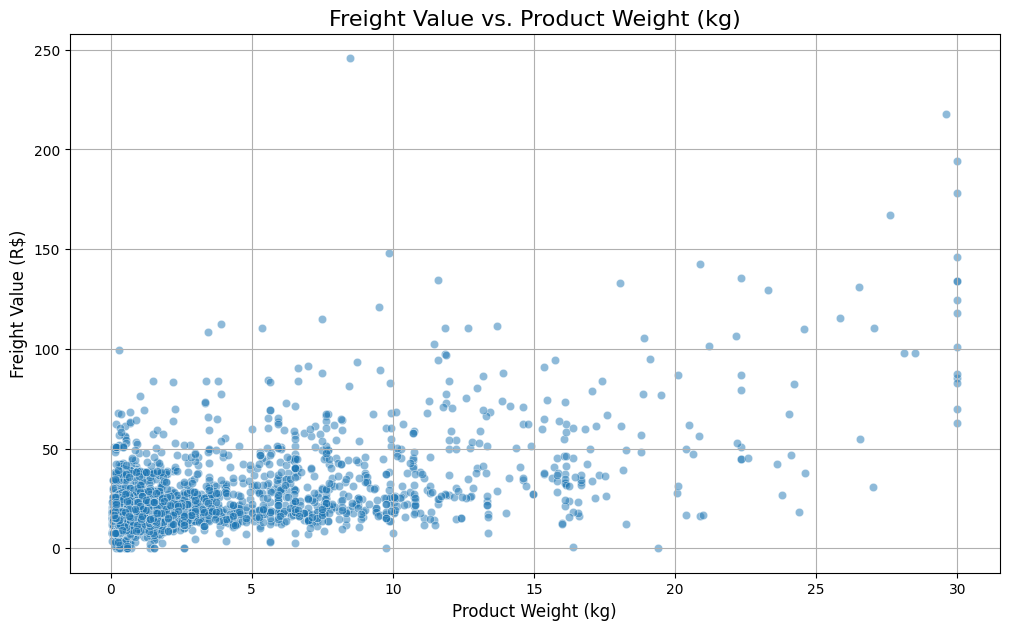

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 我们从上次确认的基准代码开始 ---
# (为了代码的完整性，这里会重复之前的加载和合并步骤，以生成我们分析所需的基础'final_df')
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
name_translation = pd.read_csv('product_category_name_translation.csv')

date_columns = [
    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date'
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
final_df = pd.merge(delivered_orders, customers, on='customer_id')
final_df = pd.merge(final_df, order_items, on='order_id')
final_df = pd.merge(final_df, products, on='product_id')
final_df = pd.merge(final_df, name_translation, on='product_category_name', how='left')
final_df['product_category_name_english'].fillna('other', inplace=True)
# --- 基准代码结束 ---


# --- 第二步：成本分析开始 ---
print("--- 开始第二步：成本分析 ---")

# 1. 计算核心成本指标
# 避免除以0的错误，如果price和freight_value都为0，则total_price也为0
final_df['total_price'] = final_df['price'] + final_df['freight_value']
# 如果total_price为0，则运费占比也为0
final_df['freight_ratio'] = np.where(final_df['total_price'] > 0, final_df['freight_value'] / final_df['total_price'], 0)


# 2. 按客户所在州（State）分析成本
state_cost_analysis = final_df.groupby('customer_state').agg(
    avg_freight_value=('freight_value', 'mean'),
    avg_freight_ratio=('freight_ratio', 'mean')
).sort_values(by='avg_freight_value', ascending=False)

print("\n--- 各州平均运费与运费占比 (平均运费最高的前10个州) ---")
print(state_cost_analysis.head(10))

# 3. 按商品品类（Product Category）分析成本
category_cost_analysis = final_df.groupby('product_category_name_english').agg(
    order_count=('order_id', 'nunique'),
    avg_freight_value=('freight_value', 'mean'),
    avg_freight_ratio=('freight_ratio', 'mean')
).sort_values(by='avg_freight_value', ascending=False)

print("\n--- 各品类平均运费与运费占比 (平均运费最高的前10个品类，订单数>30) ---")
print(category_cost_analysis[category_cost_analysis['order_count'] > 30].head(10))

# 4. 分析运费与商品重量的关系
# 清理数据：去除重量为空或异常的行，并且为了可视化效果，抽样一部分数据
weight_analysis_df = final_df.dropna(subset=['product_weight_g'])
# 将重量从克(g)转换为千克(kg)
weight_analysis_df['product_weight_kg'] = weight_analysis_df['product_weight_g'] / 1000
# 仅分析重量在合理范围内的数据，例如小于40kg，以获得更清晰的图表
weight_analysis_df_sampled = weight_analysis_df[weight_analysis_df['product_weight_kg'] < 40].sample(n=5000, random_state=1)


# 绘制散点图
plt.figure(figsize=(12, 7))
sns.scatterplot(data=weight_analysis_df_sampled, x='product_weight_kg', y='freight_value', alpha=0.5)
plt.title('Freight Value vs. Product Weight (kg)', fontsize=16)
plt.xlabel('Product Weight (kg)', fontsize=12)
plt.ylabel('Freight Value (R$)', fontsize=12)
plt.grid(True)
# 保存图表
plt.savefig('freight_vs_weight_scatter.png')

print("\n已生成运费与商品重量的关系图: freight_vs_weight_scatter.png")

In [1]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Step 1: Load the necessary datasets
try:
    customers = pd.read_csv('olist_customers_dataset.csv')
    geolocation = pd.read_csv('olist_geolocation_dataset.csv')
    print("Successfully loaded customer and geolocation datasets.")
except Exception as e:
    print(f"An error occurred during file loading: {e}")
    exit()

# Step 2: Prepare the geolocation data
# To create a unique location for each zip code, we calculate the mean lat/lon
print("Processing geolocation data...")
geo_map = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# Step 3: Prepare the customer demand data
# Count the number of customers in each zip code prefix
print("Processing customer demand data...")
demand_counts = customers['customer_zip_code_prefix'].value_counts().reset_index()
demand_counts.columns = ['customer_zip_code_prefix', 'demand_count']

# Step 4: Merge demand data with geolocation data
merged_data = pd.merge(
    demand_counts,
    geo_map,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix'
)

# Step 5: Create the heatmap
print("Generating the heatmap...")
# Create a base map centered on Brazil
brazil_map = folium.Map(location=[-14.2350, -51.9253], zoom_start=4)

# Prepare data for the HeatMap layer: list of [lat, lon, weight]
heat_data = [
    [row['geolocation_lat'], row['geolocation_lng'], row['demand_count']]
    for index, row in merged_data.iterrows()
]

# Add the HeatMap layer to the base map
HeatMap(heat_data, radius=10).add_to(brazil_map)

# Save the map to an HTML file
map_file_name = 'customer_demand_heatmap.html'
brazil_map.save(map_file_name)

print(f"\nSuccessfully generated the customer demand heatmap!")
print(f"The interactive map has been saved as: {map_file_name}")

Successfully loaded customer and geolocation datasets.
Processing geolocation data...
Processing customer demand data...
Generating the heatmap...

Successfully generated the customer demand heatmap!
The interactive map has been saved as: customer_demand_heatmap.html


In [2]:
import pandas as pd
import folium
from folium.plugins import HeatMap

print("--- 开始生成供需分布总图 ---")

# --- 第1步: 加载必要的数据集 ---
try:
    customers = pd.read_csv('olist_customers_dataset.csv')
    geolocation = pd.read_csv('olist_geolocation_dataset.csv')
    print("步骤 1/5: 成功加载客户和地理位置数据集。")
except FileNotFoundError as e:
    print(f"错误：找不到文件 {e.filename}。请确保它和脚本在同一目录。")
    exit()

# --- 第2步: 准备并绘制需求热力图 (与之前相同) ---
# 计算每个邮编前缀的平均经纬度
geo_map = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# 统计每个邮编前缀的客户数量
demand_counts = customers['customer_zip_code_prefix'].value_counts().reset_index()
demand_counts.columns = ['customer_zip_code_prefix', 'demand_count']

# 合并需求与地理数据
merged_data = pd.merge(
    demand_counts,
    geo_map,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix'
)

# 创建巴西地图底图
brazil_map = folium.Map(location=[-14.2350, -51.9253], zoom_start=4)

# 准备热力图数据
heat_data = [
    [row['geolocation_lat'], row['geolocation_lng'], row['demand_count']]
    for index, row in merged_data.iterrows()
]

# 将热力图层添加到地图上
HeatMap(heat_data, radius=10).add_to(brazil_map)
print("步骤 2/5: 客户需求热力图已生成。")


# --- 第3步: 定义核心供给中心（代理仓库） ---
# 注意：城市名称需要与 geolocation 数据集中的格式匹配 (小写, 无特殊重音符号)
supply_cities = {
    # T1 - 全国核心仓
    'sao paulo': {'tier': 'T1 - National Hub', 'color': 'red', 'icon': 'star'},
    # T2 - 区域中心仓
    'rio de janeiro': {'tier': 'T2 - Regional Hub', 'color': 'orange', 'icon': 'info-sign'},
    'belo horizonte': {'tier': 'T2 - Regional Hub', 'color': 'orange', 'icon': 'info-sign'},
    'curitiba': {'tier': 'T2 - Regional Hub', 'color': 'orange', 'icon': 'info-sign'},
    'salvador': {'tier': 'T2 - Regional Hub', 'color': 'orange', 'icon': 'info-sign'},
    # T3 - 区域节点
    'fortaleza': {'tier': 'T3 - Regional Node', 'color': 'blue', 'icon': 'glyphicon-pushpin'},
    'porto alegre': {'tier': 'T3 - Regional Node', 'color': 'blue', 'icon': 'glyphicon-pushpin'},
    'manaus': {'tier': 'T3 - Regional Node', 'color': 'blue', 'icon': 'glyphicon-pushpin'},
    'brasilia': {'tier': 'T3 - Regional Node', 'color': 'blue', 'icon': 'glyphicon-pushpin'}
}
print("步骤 3/5: 核心供给中心已定义。")


# --- 第4步: 获取并处理供给中心的坐标 ---
# 清理城市名称以便匹配
geolocation['geolocation_city'] = geolocation['geolocation_city'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# 筛选出我们需要的城市
target_city_names = list(supply_cities.keys())
city_geo_data = geolocation[geolocation['geolocation_city'].isin(target_city_names)]

# 计算每个城市的平均经纬度
city_coords = city_geo_data.groupby('geolocation_city').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

print("步骤 4/5: 成功提取供给中心坐标。")


# --- 第5步: 在地图上标记供给中心 ---
for index, city in city_coords.iterrows():
    city_name = city['geolocation_city']
    details = supply_cities[city_name]
    
    folium.Marker(
        location=[city['geolocation_lat'], city['geolocation_lng']],
        popup=f"<strong>{city_name.title()}</strong><br>{details['tier']}",
        tooltip=city_name.title(),
        icon=folium.Icon(color=details['color'], icon=details['icon'], prefix='glyphicon')
    ).add_to(brazil_map)

print("步骤 5/5: 已将所有供给中心标记在地图上。")


# --- 最后: 保存最终的地图 ---
final_map_file = 'supply_demand_distribution_map.html'
brazil_map.save(final_map_file)

print("\n🎉 恭喜！最终的供需分布总图已成功生成！")
print(f"交互式地图已保存为: {final_map_file}")

--- 开始生成供需分布总图 ---
步骤 1/5: 成功加载客户和地理位置数据集。
步骤 2/5: 客户需求热力图已生成。
步骤 3/5: 核心供给中心已定义。
步骤 4/5: 成功提取供给中心坐标。
步骤 5/5: 已将所有供给中心标记在地图上。

🎉 恭喜！最终的供需分布总图已成功生成！
交互式地图已保存为: supply_demand_distribution_map.html


In [4]:
import pandas as pd
import numpy as np

# --- 首先，复现我们项目的基准数据 ---
# (为了代码的完整性，这里会重复之前的加载和合并步骤)
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')

# 时间转换
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date']
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# 筛选已妥投订单并计算备货时长
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders['seller_prep_time_hours'] = (delivered_orders['order_delivered_carrier_date'] - delivered_orders['order_approved_at']).dt.total_seconds() / 3600

# 合并订单与订单项数据
seller_df = pd.merge(delivered_orders, order_items, on='order_id')
# --- 基准数据准备完毕 ---

print("--- 开始第四步（修正版）：卖家履约评估 ---")

# --- 创建卖家记分卡 ---
# 按 seller_id 分组，计算每个卖家的核心指标
seller_scorecard = seller_df.groupby('seller_id').agg(
    order_count=('order_id', 'nunique'),
    avg_prep_time_hours=('seller_prep_time_hours', 'mean')
).reset_index()

# 为了评估的公平性，我们只关注有一定经验的卖家（例如，订单数 > 20）
experienced_sellers = seller_scorecard[seller_scorecard['order_count'] > 20].copy()

# --- 找出高效的核心卖家 (订单多 & 发货快) ---
# 定义阈值：订单数高于平均值 & 发货时间低于平均值
order_count_threshold = experienced_sellers['order_count'].mean()
prep_time_threshold = experienced_sellers['avg_prep_time_hours'].mean()

best_sellers = experienced_sellers[
    (experienced_sellers['order_count'] > order_count_threshold) &
    (experienced_sellers['avg_prep_time_hours'] < prep_time_threshold)
].sort_values(by=['order_count', 'avg_prep_time_hours'], ascending=[False, True])


# --- 找出低效的高风险卖家 (订单多 & 发货慢) ---
worst_sellers = experienced_sellers[
    (experienced_sellers['order_count'] > order_count_threshold) &
    (experienced_sellers['avg_prep_time_hours'] > prep_time_threshold)
].sort_values(by=['order_count', 'avg_prep_time_hours'], ascending=[False, False])


print(f"\n在经验卖家（订单>20）中, 平均订单数为: {order_count_threshold:.0f} 单, 平均备货时长为: {prep_time_threshold:.2f} 小时。")

print("\n--- 高效的核心卖家 (Top 10) ---")
print("(订单量高于平均水平，发货快于平均水平)")
print(best_sellers.head(10))


print("\n--- 需要关注的低效大卖家 (Top 10) ---")
print("(订单量高于平均水平，但发货慢于平均水平)")
print(worst_sellers.head(10))

print("\n分析完成。现在我们可以基于这些发现，完成最后的项目总结。")

--- 开始第四步（修正版）：卖家履约评估 ---

在经验卖家（订单>20）中, 平均订单数为: 109 单, 平均备货时长为: 65.25 小时。

--- 高效的核心卖家 (Top 10) ---
(订单量高于平均水平，发货快于平均水平)
                             seller_id  order_count  avg_prep_time_hours
1190  6560211a19b47992c3666cc44a7e94c0         1819            28.747632
858   4a3ca9315b744ce9f8e9374361493884         1772            56.566818
2388  cc419e0650a3c5ba77189a1882b7556a         1651            57.586014
2543  da8622b14eb17ae2831f4ac5b9dab84a         1311            55.213526
1758  955fee9216a65b617aa5c0531780ce60         1261            40.554329
1450  7a67c85e85bb2ce8582c35f2203ad736         1145            37.981064
834   4869f7a5dfa277a7dca6462dcf3b52b2         1124            55.847922
1644  8b321bb669392f5163d04c59e235e066          930            48.246431
1156  620c87c171fb2a6dd6e8bb4dec959fc6          722            58.021267
1881  a1043bafd471dff536d0c462352beb48          702            36.574306

--- 需要关注的低效大卖家 (Top 10) ---
(订单量高于平均水平，但发货慢于平均水平)
                       